# Resource benchmarking of nf-core/mag v5

Six supplementary figures comparing resource use across analysis stages and tools.
Results combine one run per dataset, both with the same pipeline configuration except for
CATpack, which was run only on the ZymoBIOMICS dataset.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from mag_bench import figures as fg
from mag_bench.build import prepare

DATA = "../data"
frames = prepare(DATA)


### Figure 1. Compute use by analysis stage

CPU core-hours per job (left), jobs launched per sample (middle), and total CPU core-hours per sample (right). Analysis stages group the main tools with their associated supporting jobs, so job counts do not necessarily equal the number of tools run. Points represent individual jobs, subsampled to 500 per stage; boxplots show the distribution across both datasets when enough observations are available. Summary bars pool both datasets by dividing the total by the number of samples, ranges show dataset-specific estimates. Stages marked with an asterisk were run on a single dataset.


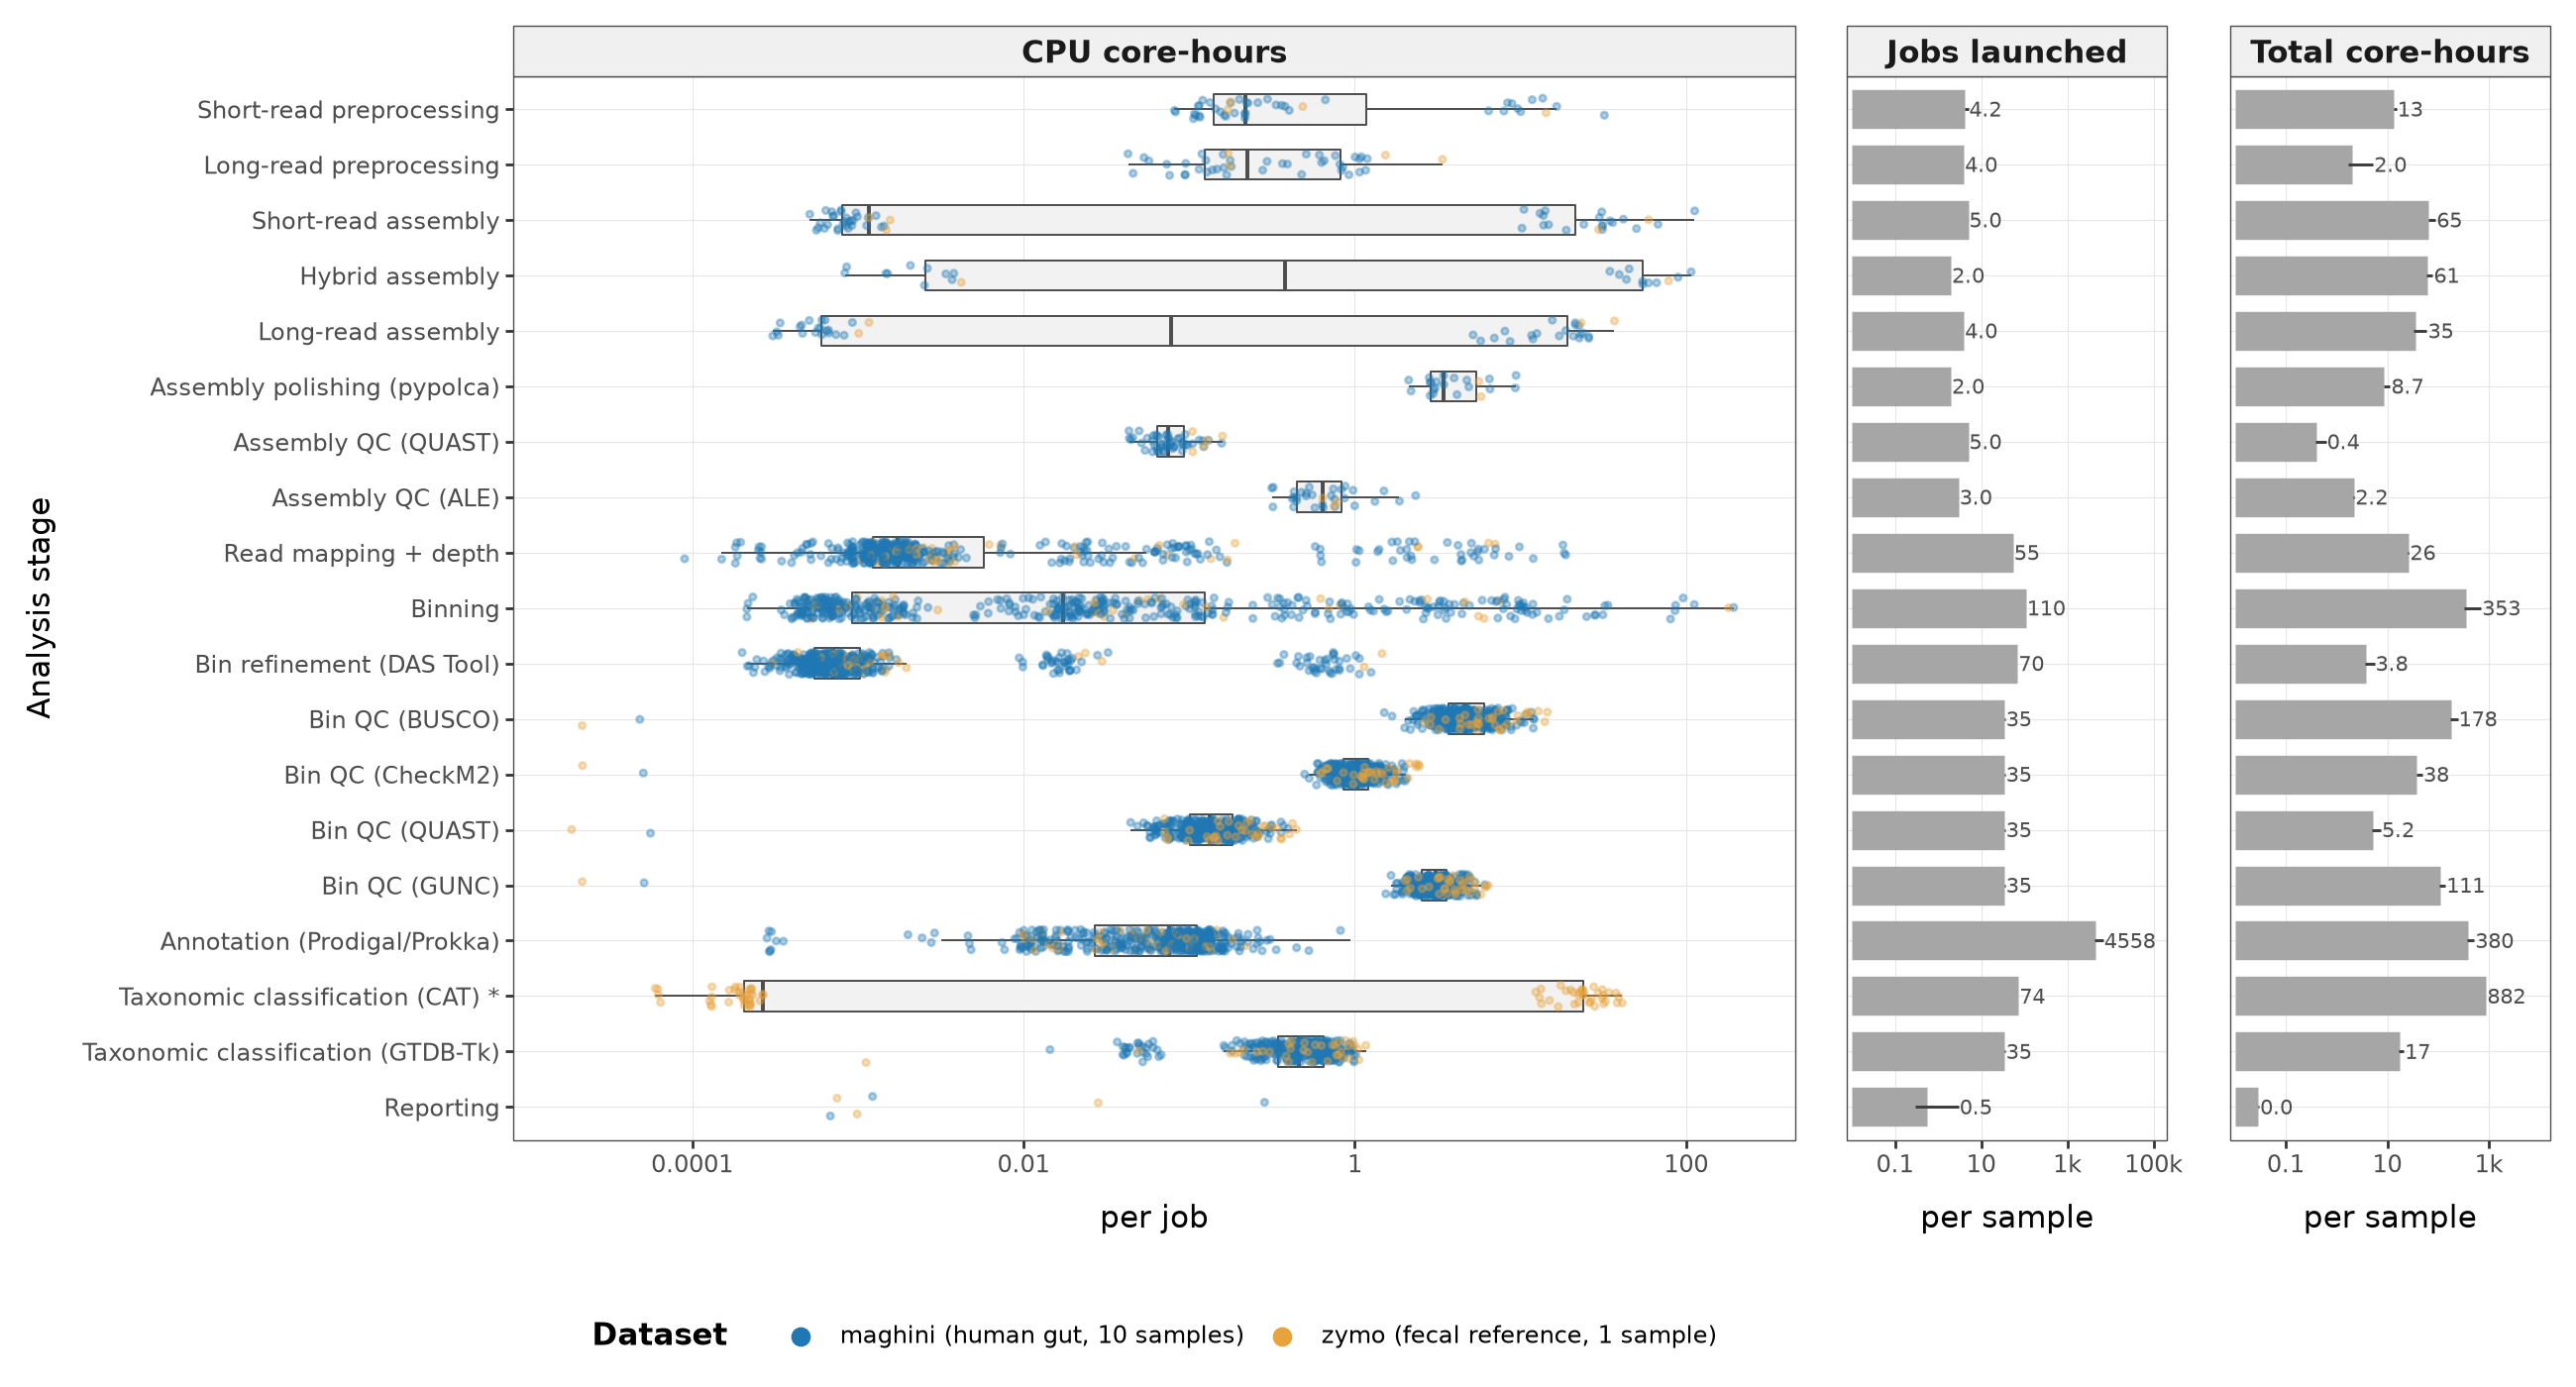

In [2]:
fg.fig_stage_compute(frames["budget"], frames["trace"])


### Figure 2. Storage per analysis stage

Data written and retained in the work directory by each analysis stage, expressed per sample. Written data includes temporary files that may be removed before workflow completion. Points represent samples, boxplots show the distribution across both datasets when enough observations are available. Stages marked with an asterisk were run on a single dataset. Assembly QC with QUAST and ALE is omitted, since both leave under 10 MB per sample on disk.


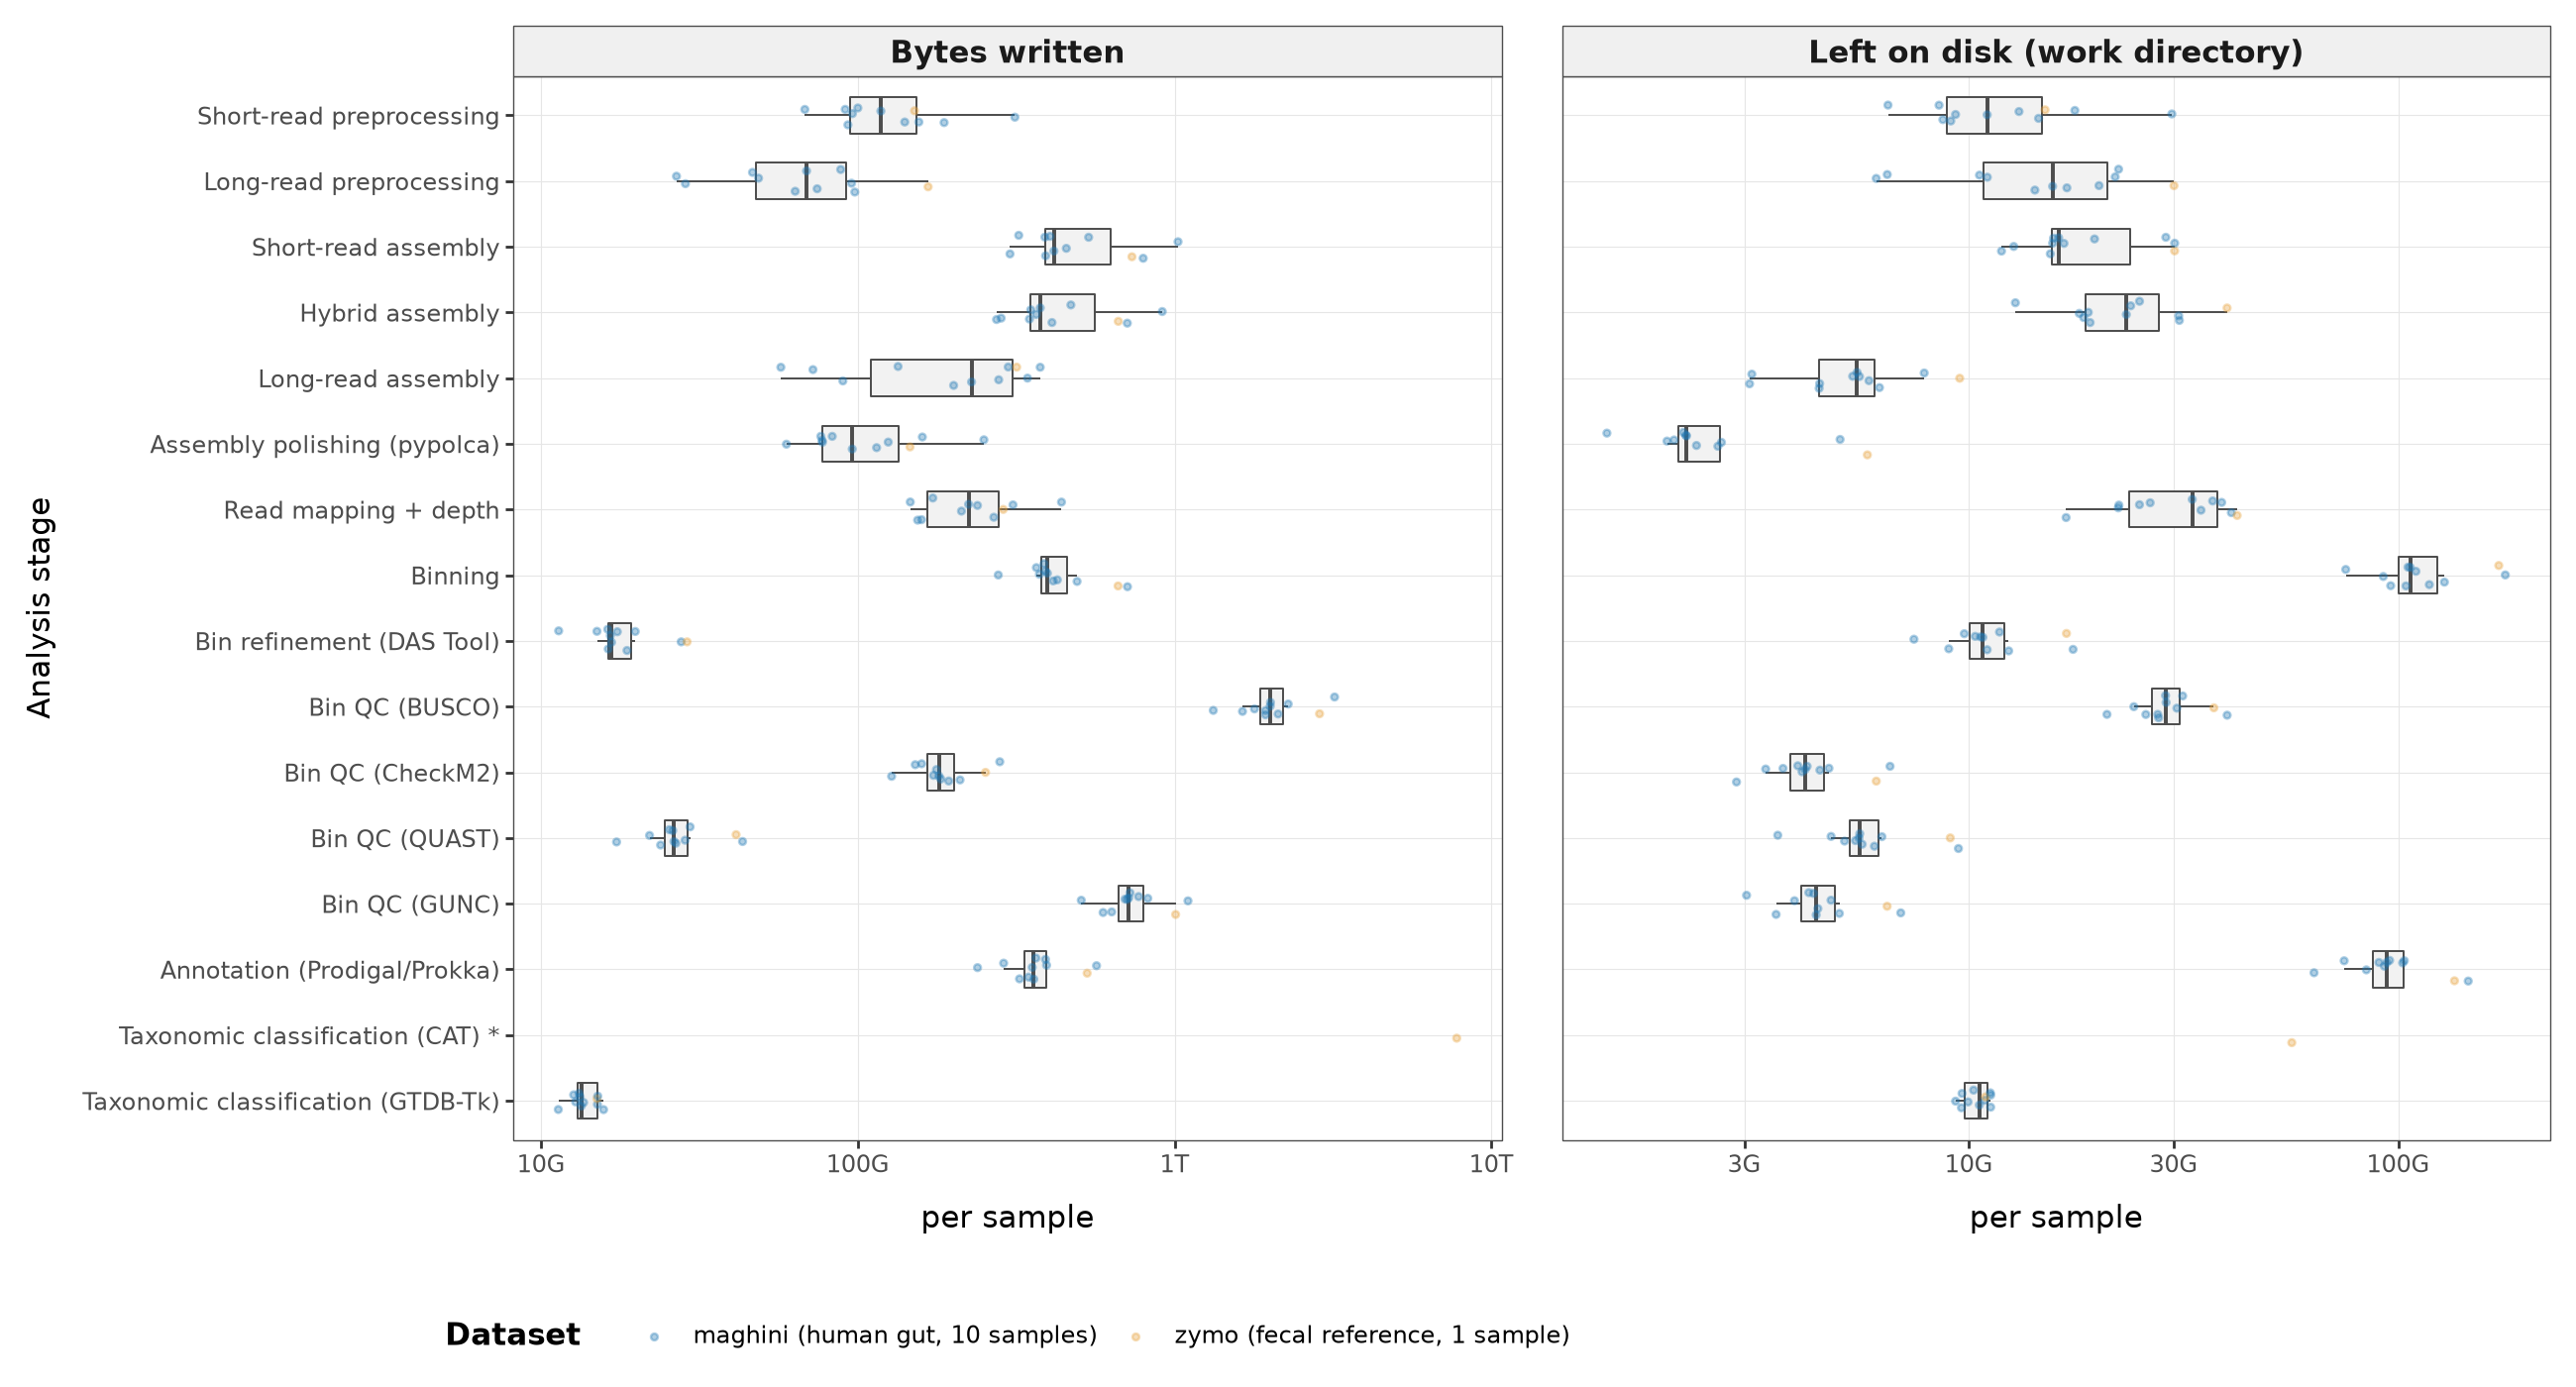

In [3]:
fg.fig_storage(frames["storage"], frames["storage_budget"])

### Figure 3. Resource footprint per assembler and binner

Peak memory, wall-clock time, and CPU core-hours for assemblers (top) and binners (bottom). Points represent individual assemblies or assembly-binner combinations, boxplots show the distribution across both datasets.


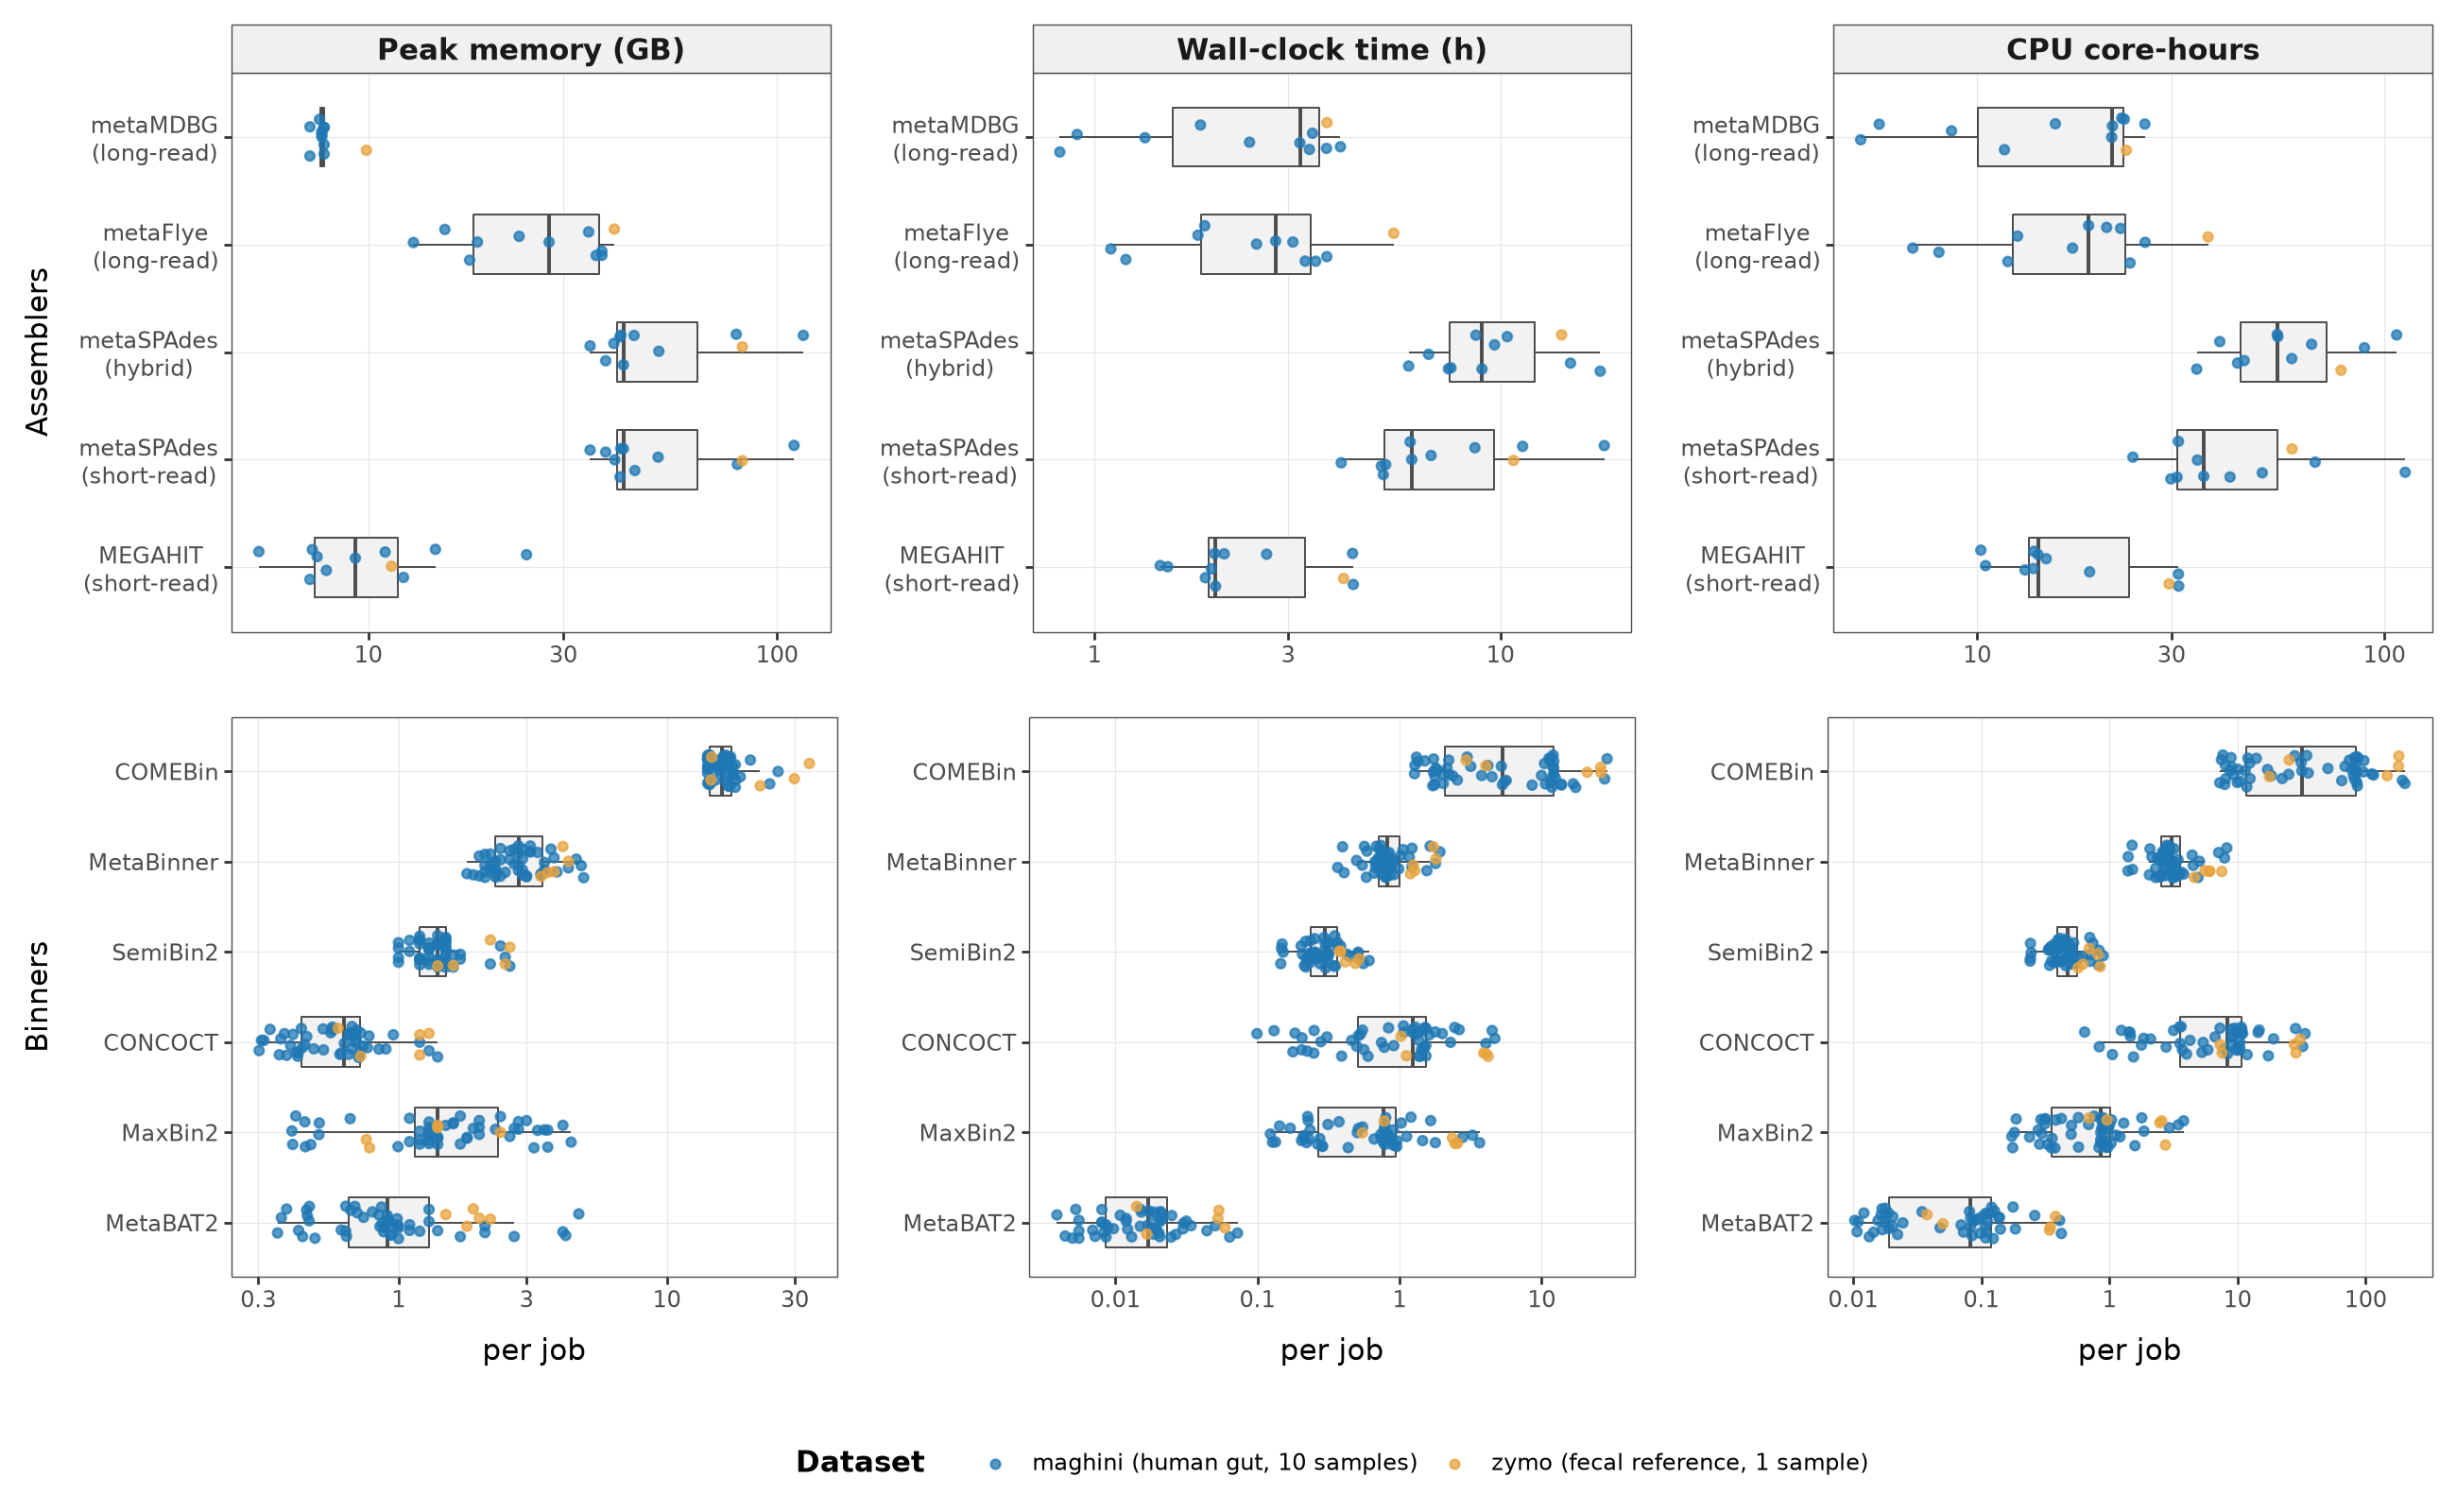

In [4]:
fg.fig_tool_footprint(frames["tasks"])

### Figure 4. Most resource-intensive processes per job

Processes with the highest median wall-clock time, peak memory, or work-directory size per job. Processes are ordered by their best rank across the three resources. Time and memory use logarithmic scales. The peak memory reported for GTDB-Tk (median 183 GB) overstates what it needs because its memory-mapped reference data is counted as resident in every job; it ran without failures on the 140 GB recommended by its developers.


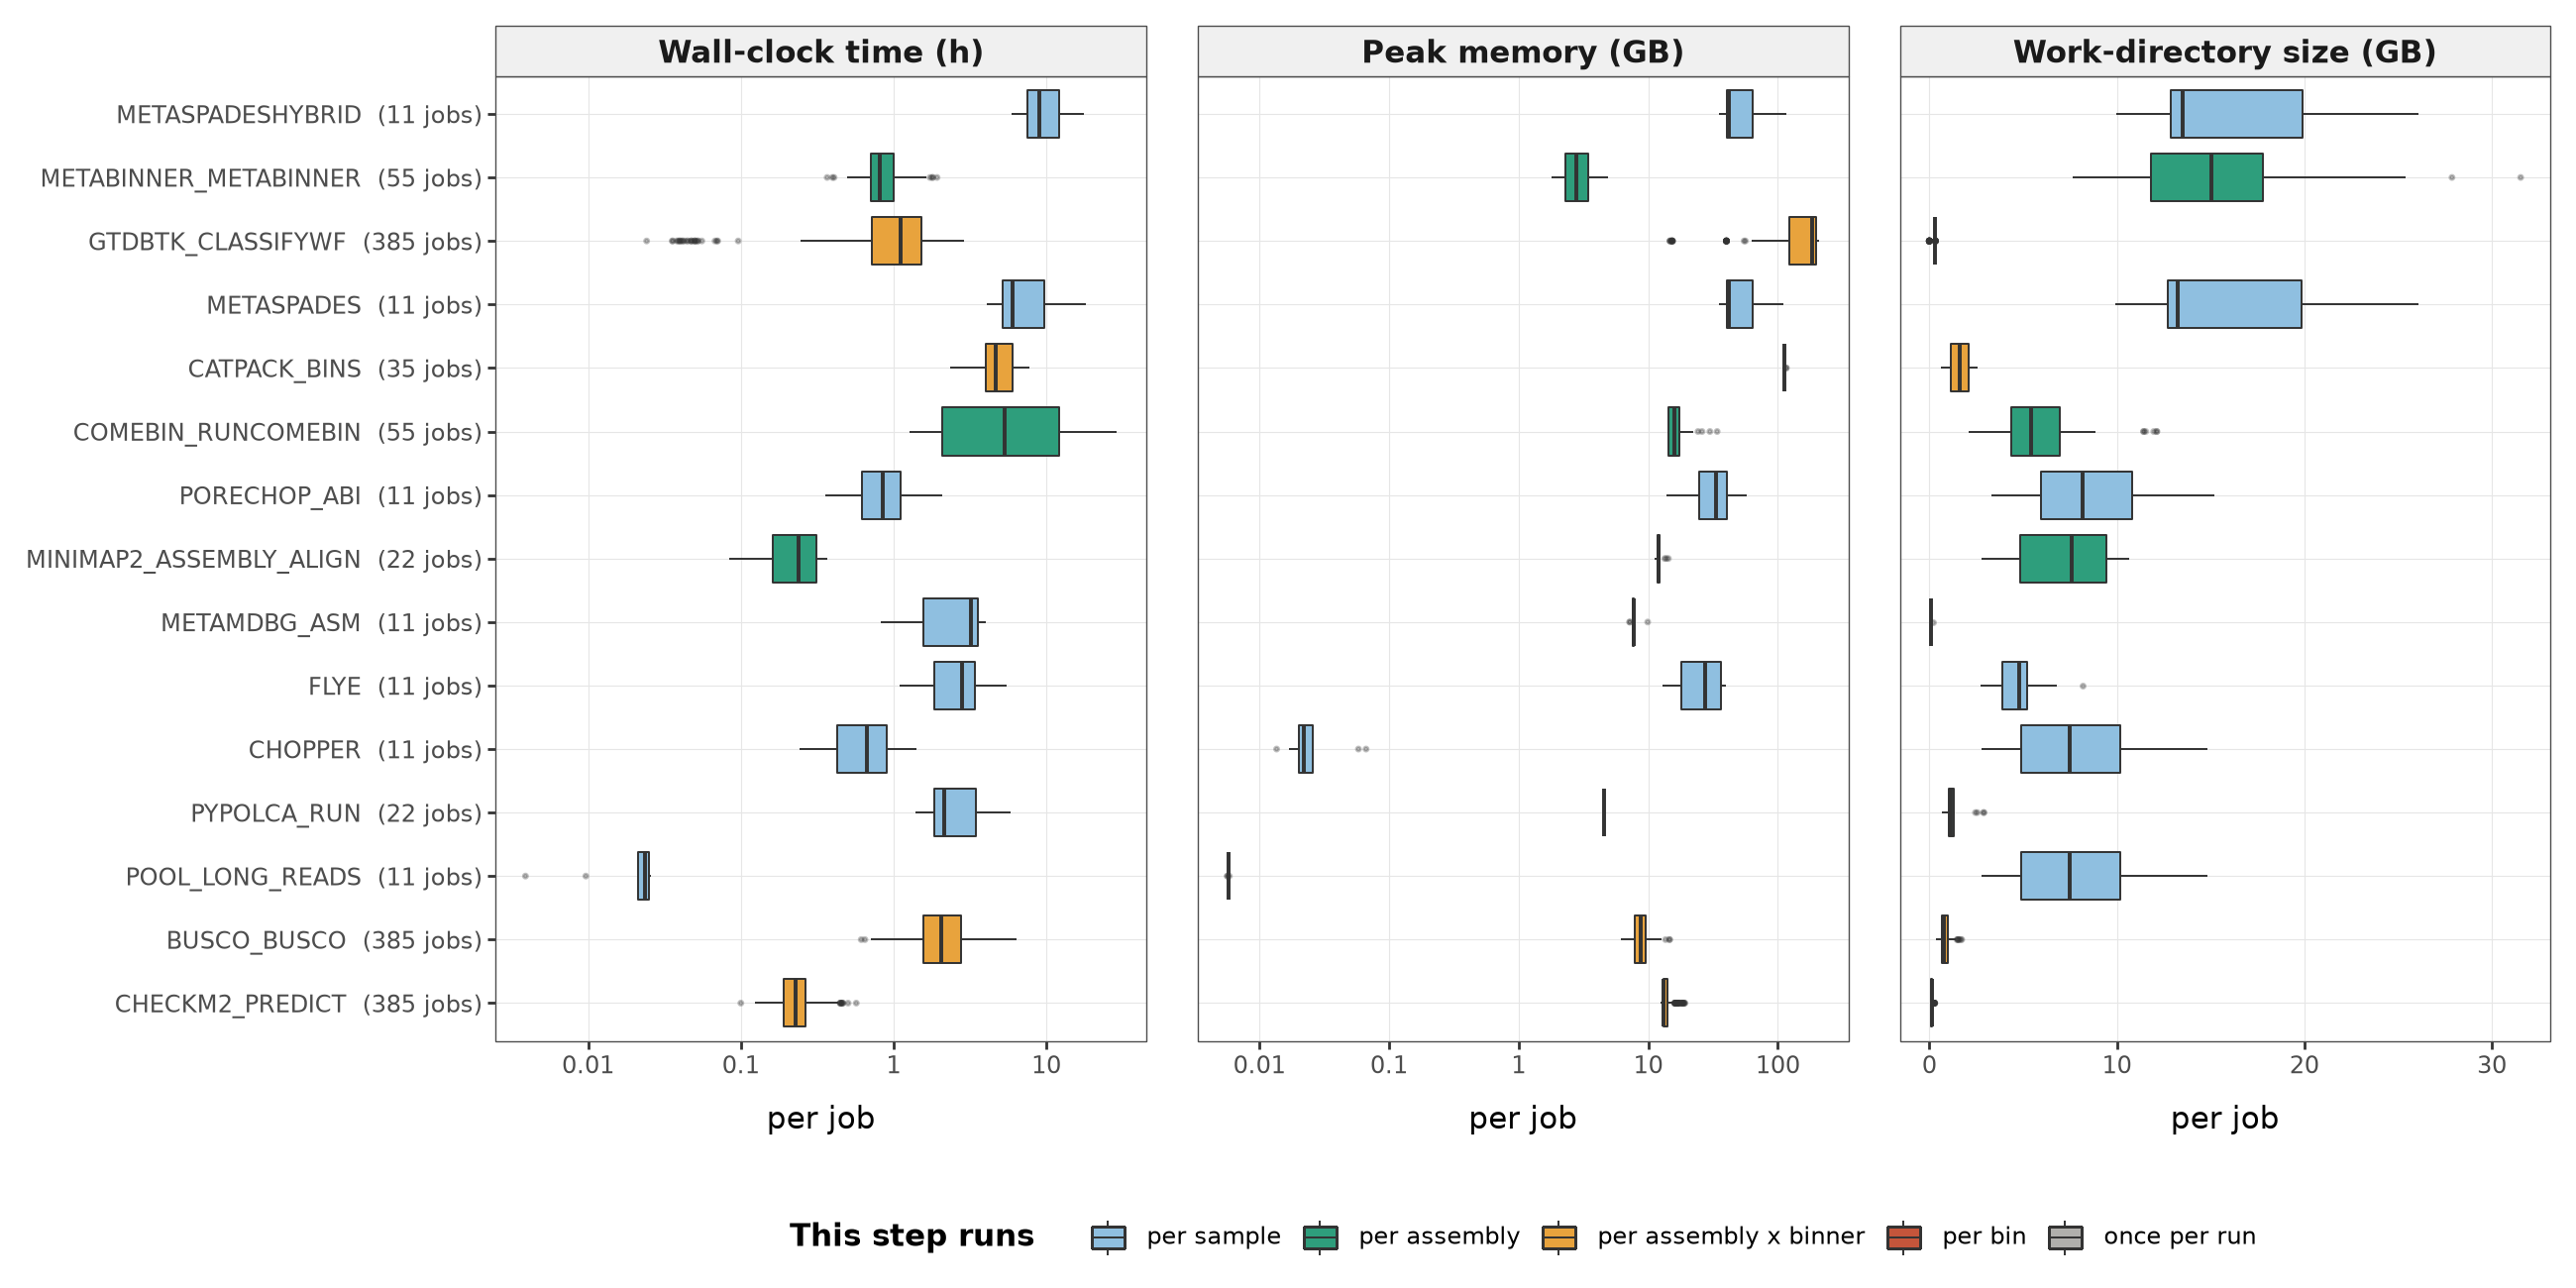

In [5]:
fg.fig_top_processes(frames["trace"])


### Figure 5. Assembler scaling with sequencing input

Assembler peak memory and CPU core-hours as a function of sequencing input. Input corresponds to short reads, long reads, or their sum according to the assembler. Points represent samples, grey bands show linear fits on log-log scales. Each panel is annotated with r, the Pearson correlation coefficient between the log-transformed variables, pooling both datasets.


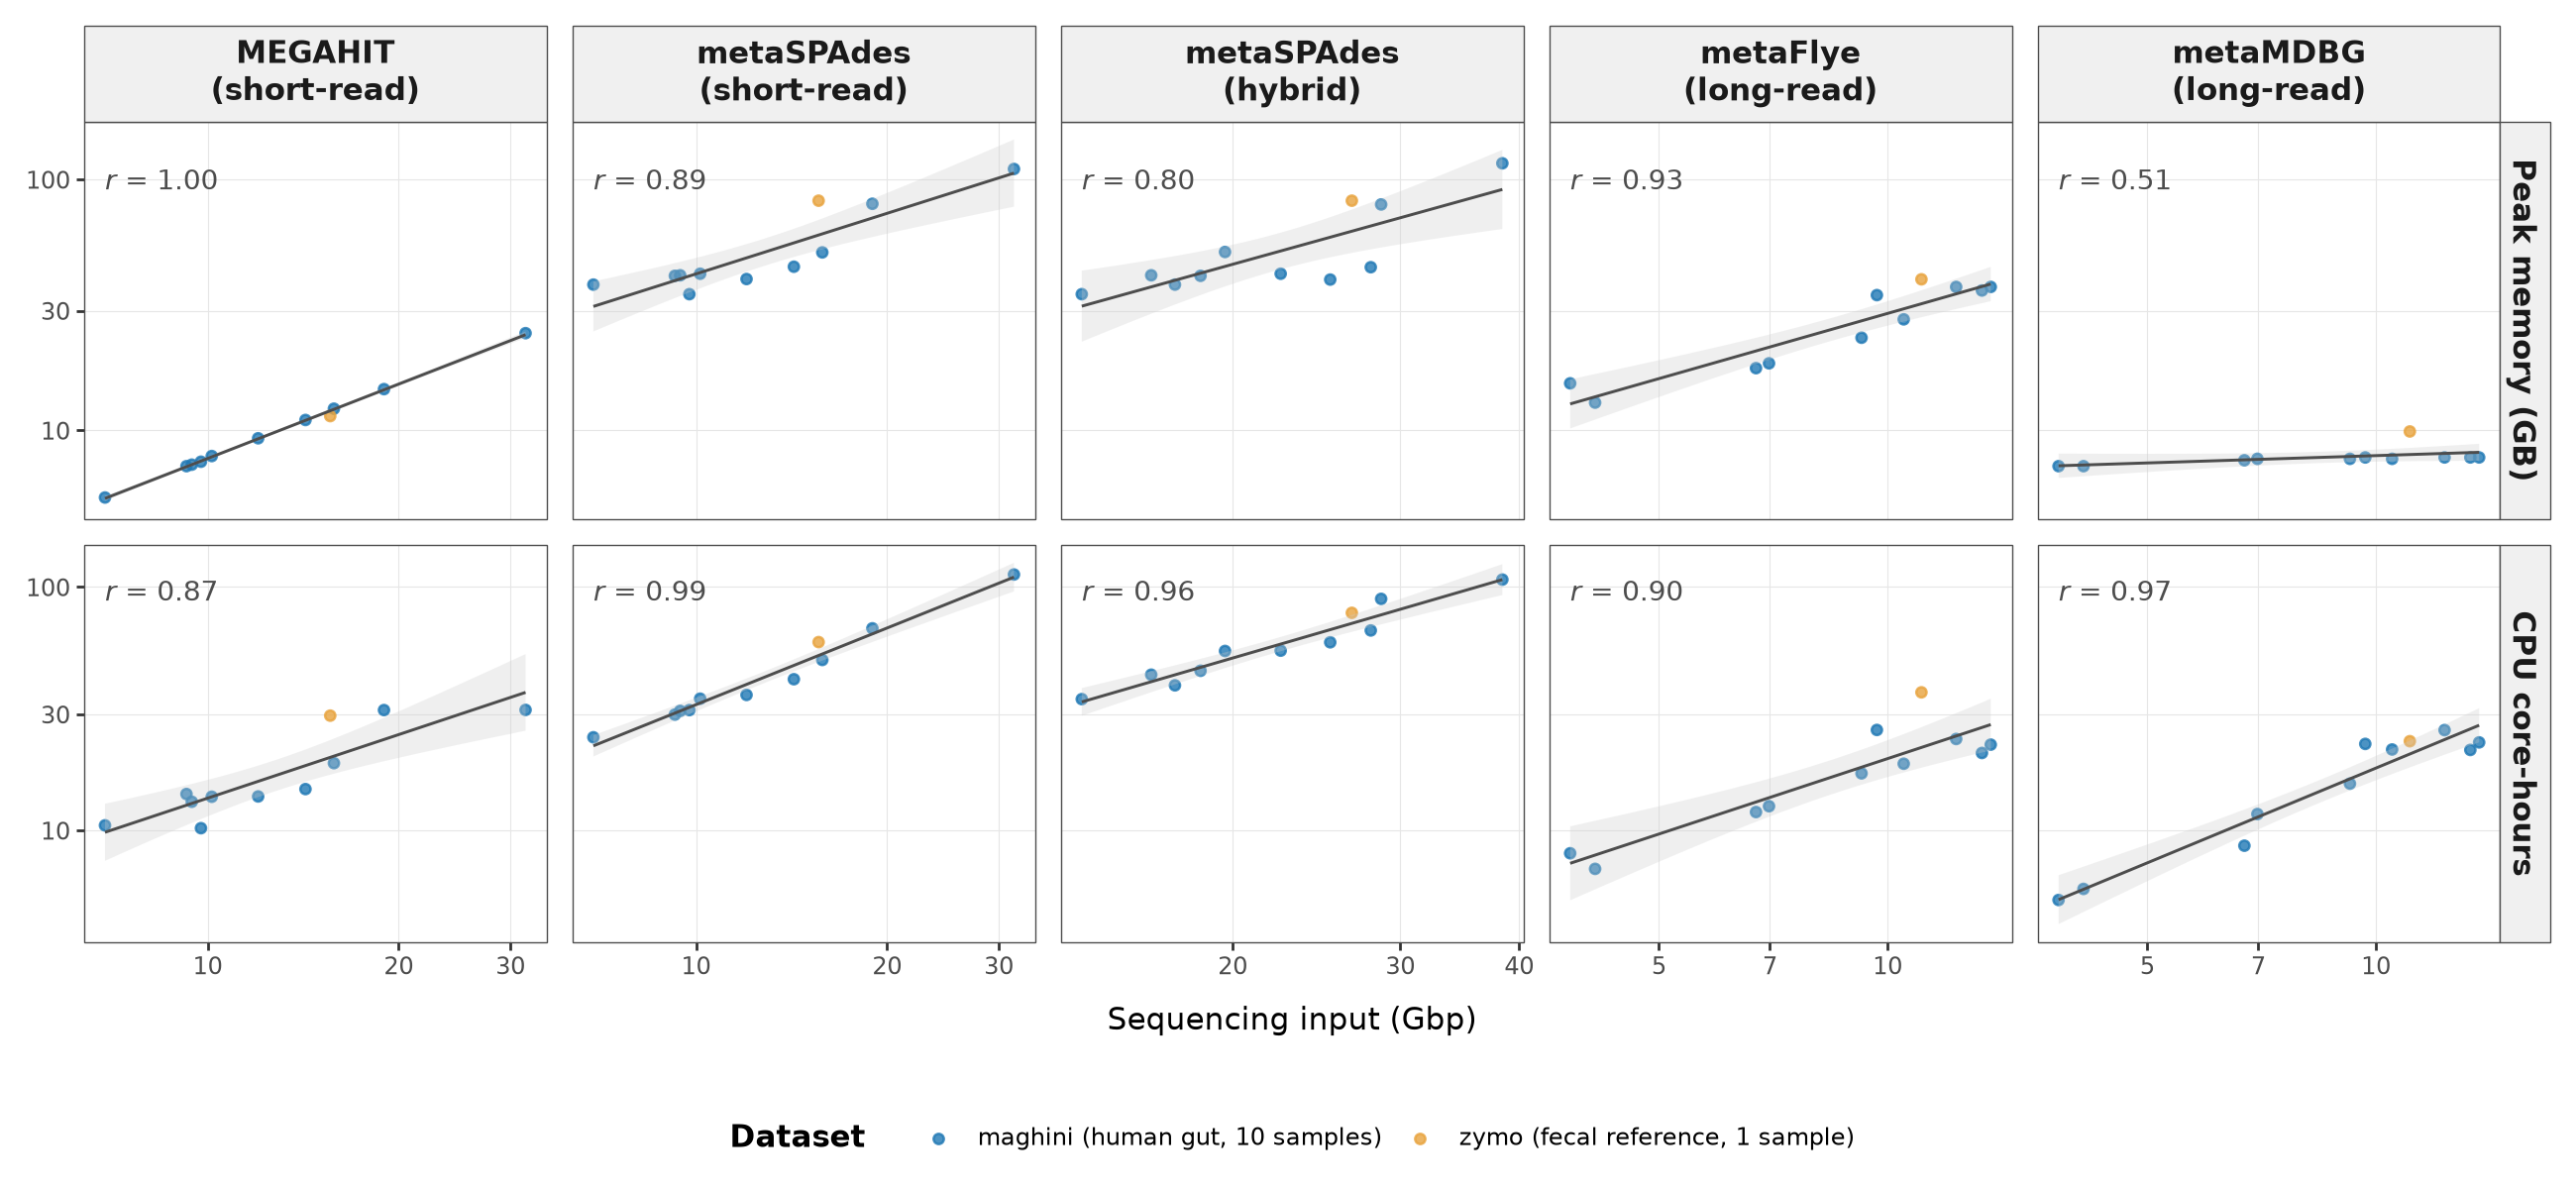

In [6]:
fg.fig_scaling_assemblers(frames["scaling"])


### Figure 6. Binner scaling with assembly size

Binner peak memory and CPU core-hours as a function of input assembly size. Points represent assembly-binner combinations, grey bands show linear fits on log-log scales. Each panel is annotated with r, the Pearson correlation coefficient between the log-transformed variables, pooling both datasets.


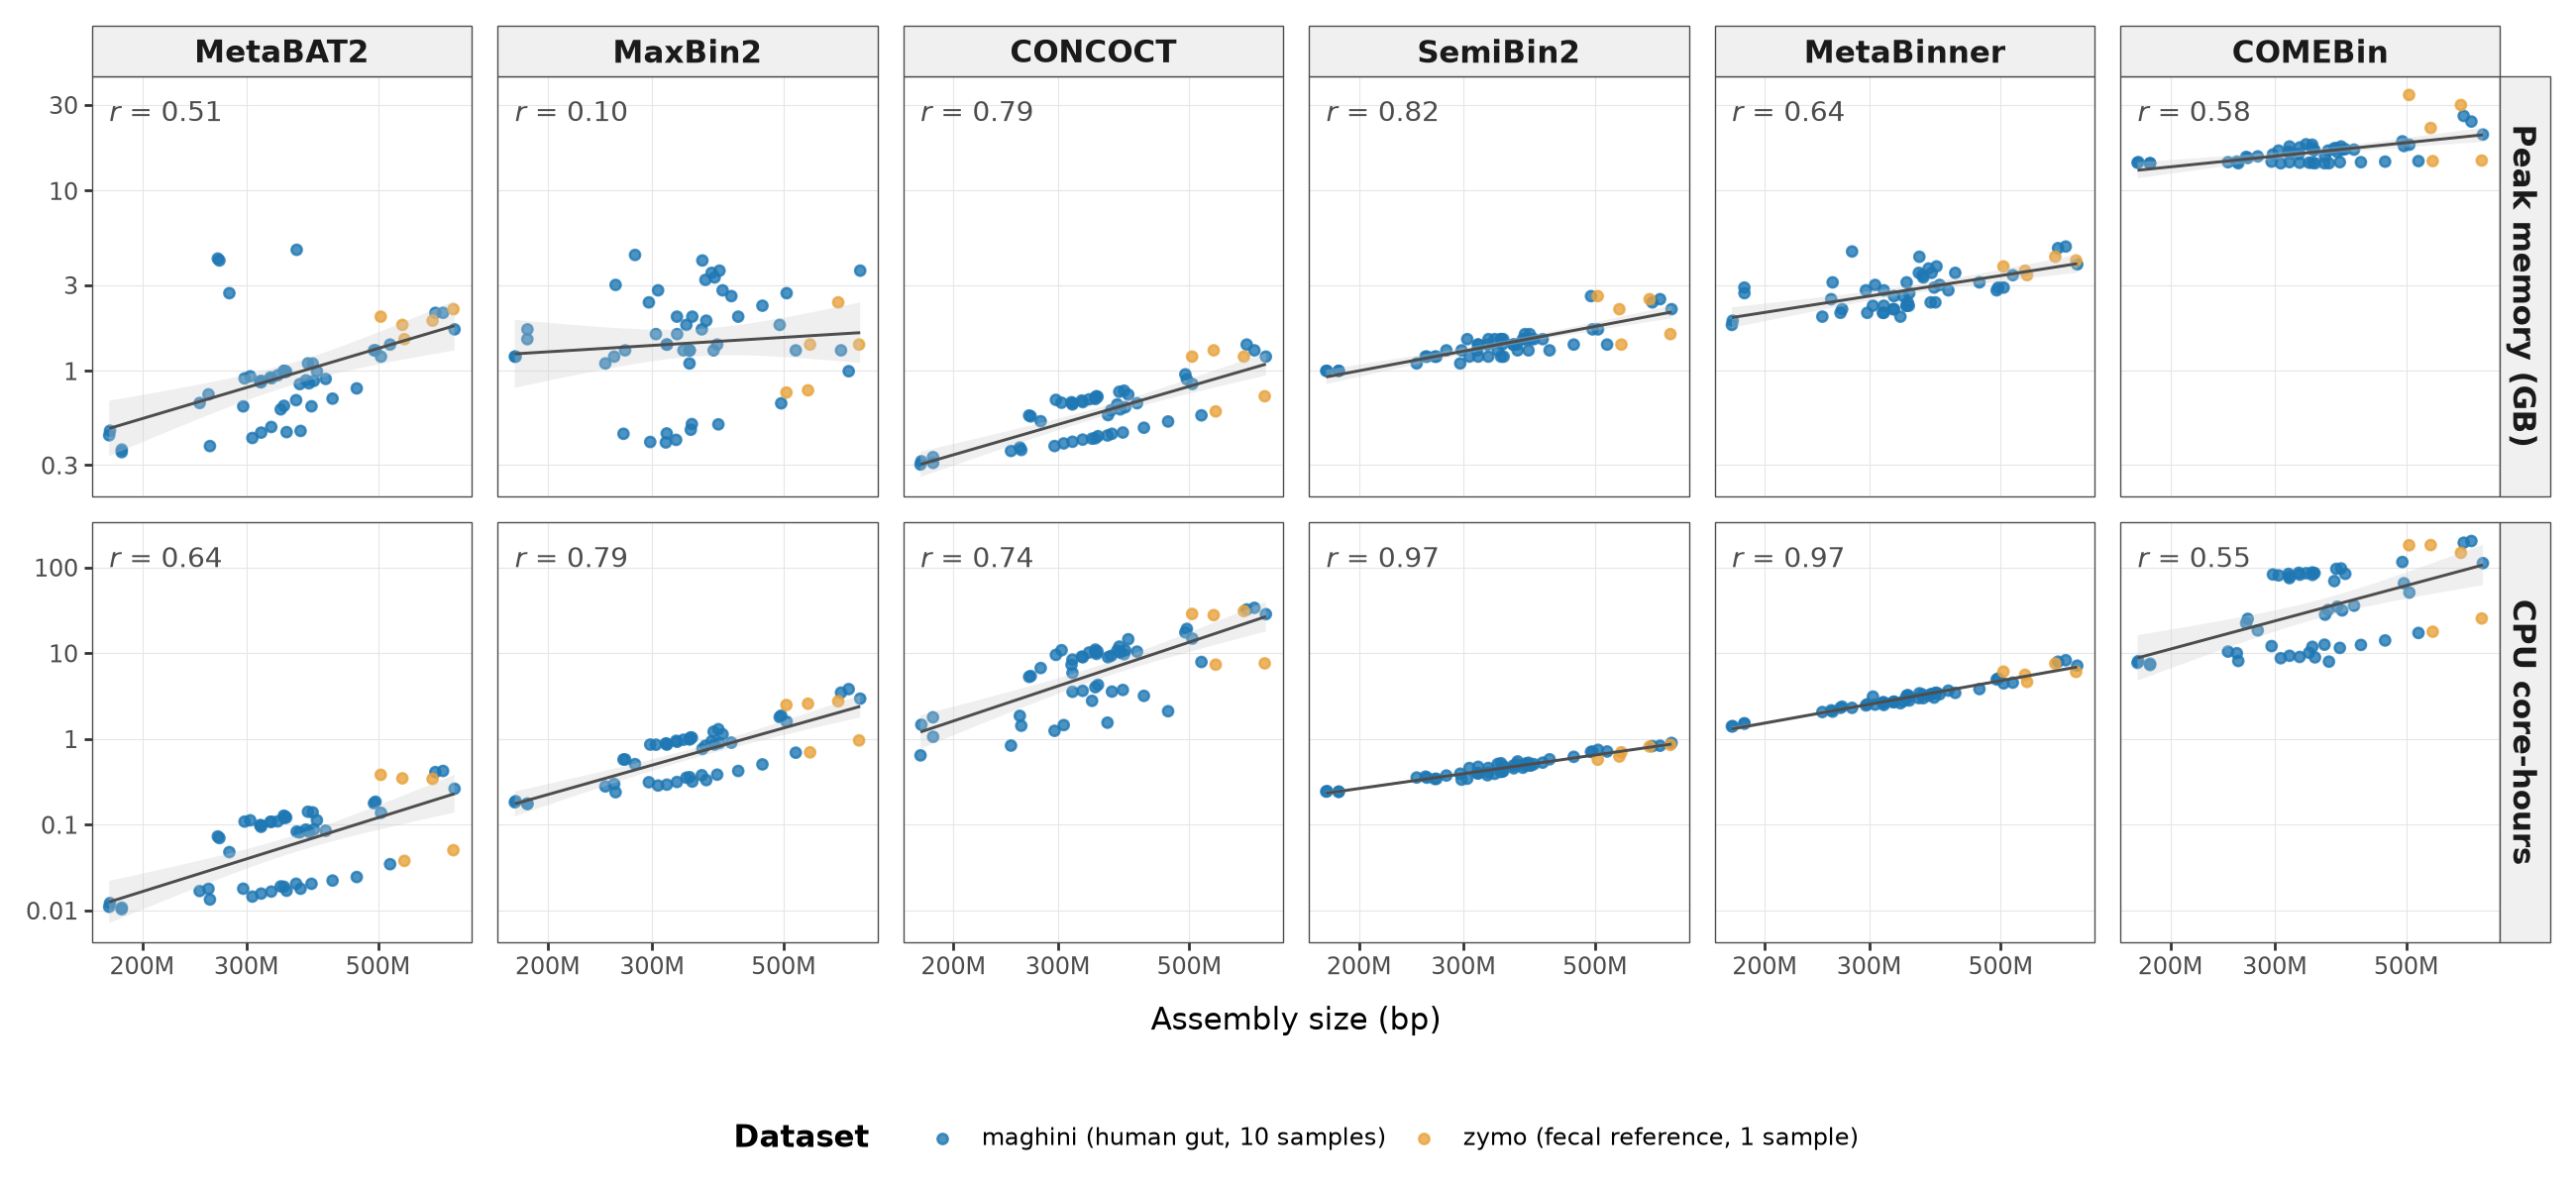

In [7]:
fg.fig_scaling_binners(frames["scaling"])

## Export


In [8]:
from mag_bench.build import build_all, save_all

save_all(build_all(DATA), out_dir="../figures", format="svg")


../figures/S1_stage_compute.svg  (1.3s)
../figures/S2_storage.svg  (0.9s)
../figures/S3_tool_footprint.svg  (1.1s)
../figures/S4_top_processes.svg  (1.3s)
../figures/S5_scaling_assemblers.svg  (0.5s)
../figures/S6_scaling_binners.svg  (0.9s)


[PosixPath('../figures/S1_stage_compute.svg'),
 PosixPath('../figures/S2_storage.svg'),
 PosixPath('../figures/S3_tool_footprint.svg'),
 PosixPath('../figures/S4_top_processes.svg'),
 PosixPath('../figures/S5_scaling_assemblers.svg'),
 PosixPath('../figures/S6_scaling_binners.svg')]